In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


### Ignore warning

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Loading Data

In [3]:
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

# Understanding Data

In [4]:
train.shape

(198000, 15)

In [5]:
test.shape

(102000, 14)

In [6]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [8]:
train.dtypes

created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

In [9]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0
label,198000.0,0.793965,0.979808,0.0,0.0,0.0,2.0,3.0


In [10]:
train.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

In [11]:
test.isnull().sum()

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

In [12]:
train['label'].nunique()

4

In [13]:
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

train["id"] = train.index + 1
test["id"] = test.index + 1
test_ids = test['id']
test = test.drop('id', axis=1)

# Handling Missing Values

In [ ]:
from sklearn.impute import SimpleImputer

most_cols = ['race', 'religion', 'gender']
most_imputer = SimpleImputer(strategy='most_frequent')

# Train
train[most_cols] = most_imputer.fit_transform(train[most_cols])
# Test
test[most_cols] = most_imputer.transform(test[most_cols])

for df in [train, test]:
    df["comment"] = df["comment"].replace(r'^\s*$', np.nan, regex=True)
    df["comment"] = df["comment"].fillna("").astype(str)
    df["disability"] = df["disability"].astype(int)

# Handling Duplicates Values

In [17]:
train.duplicated().sum()

np.int64(0)

In [18]:
test.duplicated().sum()

np.int64(4)

In [19]:
train = train.drop_duplicates()

### Checking shape after feature enginnering

In [20]:
train.shape

(198000, 95)

# Handling Outliers

In [ ]:
num_cols = [c for c in train.select_dtypes(include="number").columns if c != "label"]

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
def cap_outliers(df, cols):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.clip(df[col], lower, upper)
    return df

train = cap_outliers(train, num_cols)

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    test[col] = np.clip(test[col], lower, upper)

# Charts for Analysis

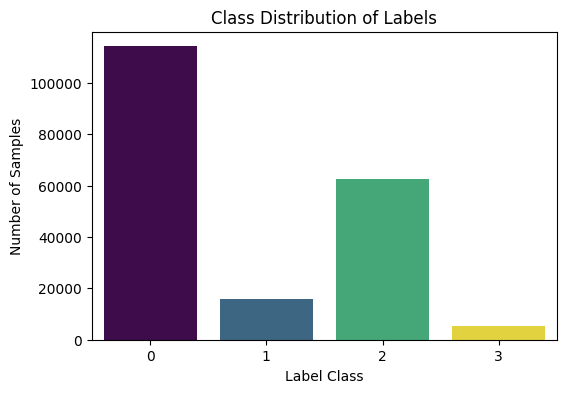

In [24]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=train,
    x="label",
    hue="label",
    palette="viridis",
    legend=False
)

plt.title("Class Distribution of Labels", fontsize=12)
plt.xlabel("Label Class")
plt.ylabel("Number of Samples")
plt.show()

- Models may bias toward class 0
- Macro F1 is harder to optimize
- Class 3 is hardest to predict

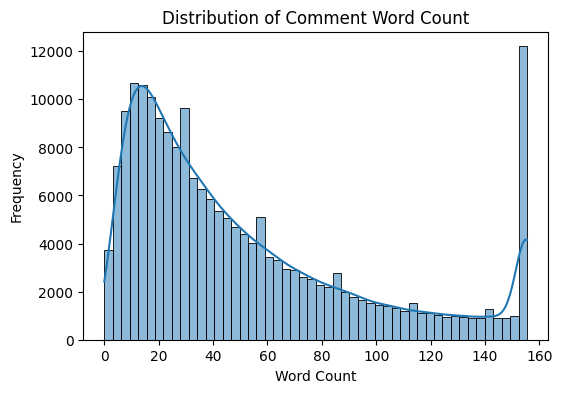

In [25]:
plt.figure(figsize=(6,4))

sns.histplot(
    train["word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Comment Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

- Most comments are short
- Word count is an important feature
- Distribution is right-skewed

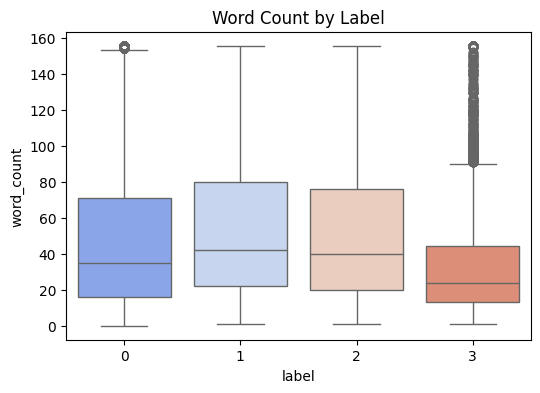

In [26]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=train,
    x="label",
    y="word_count",
    palette="coolwarm"
)

plt.title("Word Count by Label")
plt.show()

- This suggests these label 0 comments tend to be longer discussions or explanations.
- Label 3 comments are usually shorter messages.

In [ ]:
important_cols = num_cols = [c for c in train.select_dtypes(include="number").columns if c != "label"]
plt.figure(figsize=(8,6))

corr = train[important_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

- Longer comments slightly tend to include more questions.
- Longer comments usually have less uppercase ratio.
- if_2 feature is more related to labels

# Feature Engineering

In [ ]:
import re
for df in [train, test]:
    df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
    df["hour"] = df["created_date"].dt.hour
    df["weekday"] = df["created_date"].dt.weekday
    df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)
    df["is_night"] = df["hour"].isin([22, 23, 0, 1, 2, 3]).astype(int)
    df["is_morning"] = df["hour"].isin([6, 7, 8, 9]).astype(int)
    df["is_afternoon"] = df["hour"].isin([12, 13, 14, 15, 16]).astype(int)

    df["comment_len"] = df["comment"].fillna("").apply(len)
    df["exclamation"] = df["comment"].fillna("").apply(lambda x: x.count("!"))
    df["question"] = df["comment"].fillna("").apply(lambda x: x.count("?"))
    df["caps_ratio"] = df["comment"].fillna("").apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    df["punct_count"] = df["comment"].fillna("").apply(lambda x: sum(1 for c in x if c in "!?.,;:"))
    df["digit_count"] = df["comment"].fillna("").apply(lambda x: sum(1 for c in x if c.isdigit()))
    df["space_count"] = df["comment"].fillna("").apply(lambda x: x.count(" "))
    df["url_count"] = df["comment"].fillna("").apply(lambda x: len(re.findall(r'http\S+', x)))
    df["mention_count"] = df["comment"].fillna("").apply(lambda x: x.count("@"))
    df["hashtag_count"] = df["comment"].fillna("").apply(lambda x: x.count("#"))
    df["has_emoticon"] = (df["total_emoticons"] > 0).astype(int)

    # Text sentiment signals
    df["has_negative_words"] = df["comment"].fillna("").apply(lambda x: int(any(w in x.lower() for w in ["hate", "stupid", "idiot", "kill", "disgusting", "ugly", "trash", "dumb"])))
    df["has_positive_words"] = df["comment"].fillna("").apply(lambda x: int(any(w in x.lower() for w in ["love", "great", "amazing", "wonderful", "excellent", "good", "best"])))

In [ ]:
train.drop(columns=["created_date"], inplace=True)
test.drop(columns=["created_date"], inplace=True)

# Splitting Data

In [29]:
from sklearn.model_selection import train_test_split

X = train.drop("label", axis=1)
y = train["label"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,  stratify=y)

# Preprocessing

In [ ]:
num_cols = [c for c in train.select_dtypes(include="number").columns if c != "label"]
cat_cols = ["race", "religion", "gender"]

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

word_tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'\w{1,}',
)

# Char-level TF-IDF (captures slang, misspellings)
char_tfidf = TfidfVectorizer(
    ngram_range=(2, 6),
    sublinear_tf=True,
    min_df=3,
    strip_accents='unicode',
    analyzer='char_wb',
)

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("word", word_tfidf, "comment"),
        ("char", char_tfidf, "comment"),
        ("num", MinMaxScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(test)

In [ ]:
X_train_t.shape

# Choosing Best K features

In [34]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=155000)

X_train_fs = selector.fit_transform(X_train_t, y_train)
X_val_fs = selector.transform(X_val_t)
X_test_fs = selector.transform(X_test_t)

## Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

lr = LogisticRegression(
    C=2,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=4000,
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_fs, y_train)

# Evaluate
val_preds = lr.predict(X_val_fs)

print("Logistic Regression Accuracy:", accuracy_score(y_val, val_preds))
print("Logistic Regression Macro F1:", f1_score(y_val, val_preds, average="macro"))
print(classification_report(y_val, val_preds))

Logistic Regression Accuracy: 0.9130303030303031
Logistic Regression Macro F1: 0.824820448239907
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.71      0.86      0.78      3183
           2       0.89      0.89      0.89     12488
           3       0.60      0.76      0.67      1094

    accuracy                           0.91     39600
   macro avg       0.80      0.86      0.82     39600
weighted avg       0.92      0.91      0.92     39600



## SGD Regression

In [36]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

sgd = SGDClassifier(
    loss="modified_huber",
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    tol=1e-3,
    alpha=1e-5,
)
sgd.fit(X_train_fs, y_train)

# Evaluate
val_preds = sgd.predict(X_val_fs)

print("SGD Classifier Accuracy:", accuracy_score(y_val, val_preds))
print("SGD Classifier Macro F1:", f1_score(y_val, val_preds, average="macro"))
print(classification_report(y_val, val_preds))

SGD Classifier Accuracy: 0.9144696969696969
SGD Classifier Macro F1: 0.8097527672870881
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.81      0.73      0.77      3183
           2       0.84      0.94      0.89     12488
           3       0.78      0.52      0.62      1094

    accuracy                           0.91     39600
   macro avg       0.85      0.78      0.81     39600
weighted avg       0.92      0.91      0.91     39600



## Linear SVC

In [37]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

svc = LinearSVC(C=0.2, class_weight='balanced', max_iter=5000)
svc.fit(X_train_fs, y_train)

# Evaluate
val_preds = svc.predict(X_val_fs)

print("LinearSVC Accuracy:", accuracy_score(y_val, val_preds))
print("LinearSVC Macro F1:", f1_score(y_val, val_preds, average="macro"))
print(classification_report(y_val, val_preds))

LinearSVC Accuracy: 0.916540404040404
LinearSVC Macro F1: 0.830653054672078
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.75      0.83      0.78      3183
           2       0.87      0.91      0.89     12488
           3       0.70      0.68      0.69      1094

    accuracy                           0.92     39600
   macro avg       0.82      0.84      0.83     39600
weighted avg       0.92      0.92      0.92     39600



# Decomposition of Features

In [38]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=500, random_state=42)
X_train_svd = svd.fit_transform(X_train_fs)
X_val_svd = svd.transform(X_val_fs)
X_test_svd = svd.transform(X_test_fs)
print(f"Explained variance: {svd.explained_variance_ratio_.sum():.3f}")

Explained variance: 0.926


## MLP Classifier

In [39]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation="relu",
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_train_svd, y_train)

# Evaluate
val_preds = mlp.predict(X_val_svd)

print("MLP Accuracy:", accuracy_score(y_val, val_preds))
print("MLP Macro F1:", f1_score(y_val, val_preds, average="macro"))
print(classification_report(y_val, val_preds))

MLP Accuracy: 0.8991161616161616
MLP Macro F1: 0.7741505605293723
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     22835
           1       0.73      0.78      0.75      3183
           2       0.84      0.89      0.86     12488
           3       0.68      0.43      0.52      1094

    accuracy                           0.90     39600
   macro avg       0.80      0.76      0.77     39600
weighted avg       0.90      0.90      0.90     39600



# Comparing Models

In [40]:
results = {
    "Logistic Regression": 0.823,
    "SGD Classifier": 0.822,
    "Linear SVC" : 0.830,
    "MLP Classifier": 0.780
}

results_df = pd.DataFrame(list(results.items()),columns=["Model", "Macro F1"])

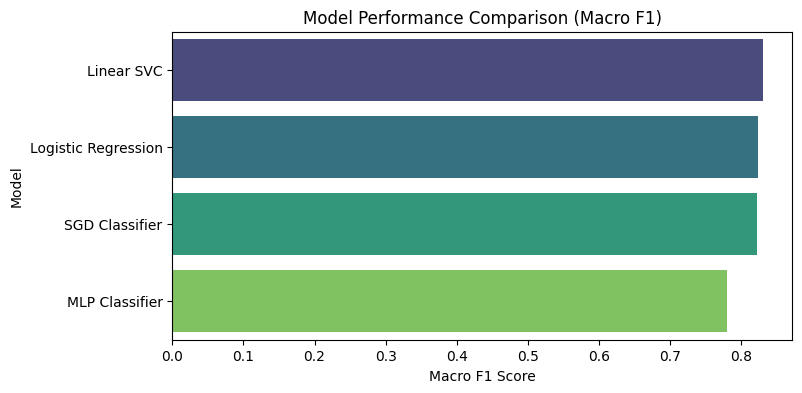

In [41]:
plt.figure(figsize=(8,4))

results_df_sorted = results_df.sort_values(by="Macro F1", ascending=False)

sns.barplot(
    data=results_df_sorted,
    x="Macro F1",
    y="Model",
    palette="viridis"
)

plt.title("Model Performance Comparison (Macro F1)")
plt.xlabel("Macro F1 Score")
plt.ylabel("Model")

plt.show()

# Retrain Training on full data

In [42]:
from scipy.sparse import vstack

X_full = vstack([X_train_fs, X_val_fs])
y_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

In [43]:
svc_final = LinearSVC(C=0.2, class_weight='balanced', max_iter=5000)
svc_final.fit(X_full, y_full)

LinearSVC(C=0.2, class_weight='balanced', max_iter=5000)

# Final Submission

In [44]:
test_preds = svc_final.predict(X_test_fs)
submission = pd.DataFrame({
    "ID": test_ids,
    "label": test_preds
})

submission.to_csv("submission.csv", index=False)
print(submission.head())

   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
